# Custom Selector Function

Often times we want better control over the selection process. To this end, we can set the `selector_func` argument with a "custom selector function" to override the default `model-based` selection. This allows us to implement more complex selection logic and state-based transitions.

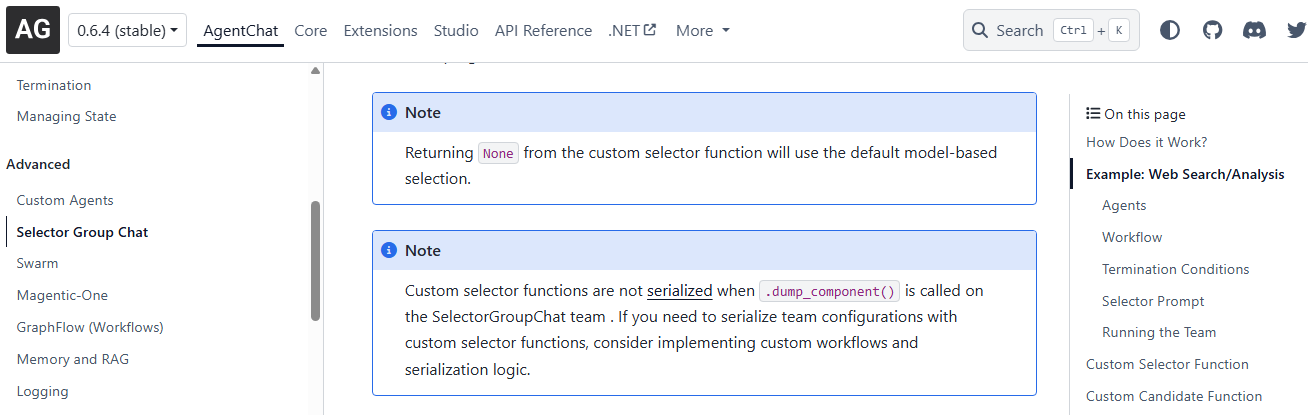

##### ***Reference URL:*** https://microsoft.github.io/autogen/stable//user-guide/agentchat-user-guide/selector-group-chat.html#custom-selector-function

In [14]:
import asyncio
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.teams import SelectorGroupChat
from autogen_agentchat.messages import TextMessage
from autogen_agentchat.conditions import TextMentionTermination,MaxMessageTermination

In [15]:
import os
from dotenv import load_dotenv

# Load API key
load_dotenv()
api_key= os.getenv('OPENAI_API_KEY')

In [16]:
# Model client

model_client= OpenAIChatCompletionClient(model='gpt-4o', api_key=api_key)
model_client

In [17]:
# Planning Assistant Agent

planning_agent= AssistantAgent(
    name="PlanningAgent",
    description="An agent for planning tasks, this agent should be the first to engage when given a new task.",
    system_message="""
    You are a planning agent.
    Your job is to break down complex tasks into smaller, manageable subtasks.
    Your team members are:
        WebSearchAgent: Searches for information
        DataAnalystAgent: Performs calculations

    You only plan and delegate tasks - you do not execute them yourself.

    When assigning tasks, use this format:
    1. <agent> : <task>

    After all tasks are complete, summarize the findings and end with "TERMINATE".
    """,
    model_client=model_client
)

In [18]:
# Search Web Tool

def search_web_tool(query: str) -> str:
    # Simulate a web search
    if "2006-2007" in query:
        return """Here are the total points scored by Miami Heat players in the 2006-2007 season:
        Udonis Haslem: 844 points
        Dwayne Wade: 1397 points
        James Posey: 550 points
        ...
        """
    elif "2007-2008" in query:
        return "The number of total rebounds for Dwayne Wade in the Miami Heat season 2007-2008 is 214."
    elif "2008-2009" in query:
        return "The number of total rebounds for Dwayne Wade in the Miami Heat season 2008-2009 is 398."
    return "No data found."

In [19]:
# Web Search Assistant Agent

web_search_agent= AssistantAgent(
    name="WebSearchAgent",
    description="An agent for searching the web for information.",
    system_message="""
        You are a web search agent.
        Your only tool is search_web_tool - use it to find the information you need.
        You make only one search call at a time.   
        Once you have the results, you never do calculations or data analysis on them.
    """,
    model_client=model_client,
    tools= [search_web_tool],
    reflect_on_tool_use= False
    
)

In [20]:
def percentage_change_tool(start:float, end:float) -> float:
    '''Calculate percentage change'''
    
    if start == 0:
        return 0
    return ((end - start) / start) * 100

In [21]:
# Data Analyst Assistant Agent

data_analyst_agent= AssistantAgent(
    name="DataAnalystAgent",
    description="An agent for performing calculations and data analysis.",
    system_message="""
        You are a data analyst agent.
        Given the tasks you have been assigned, you should analyze the data and provide results using the tools provided.
        If you have not seen the data, ask for it.
    """,
    model_client=model_client,
    tools= [percentage_change_tool]
)

In [22]:
# Termination Condition
from autogen_agentchat.conditions import TextMentionTermination, MaxMessageTermination

text_mention_termination= TextMentionTermination(text="TERMINATE")
max_message_termination= MaxMessageTermination(max_messages=20)

combined_termination= text_mention_termination | max_message_termination

In [23]:
selector_prompt='''

Select an agent to perform the task.

{roles}

current conversation history :
{history}

Read the above conversation, then select an agent from {participants} to perform the next task.
Make sure that the planning agent has assigned task before other agents start working.
Only select one agent.
'''

In [24]:
# Define Selector Teams with Custom Selector Function

from autogen_agentchat.messages import BaseAgentEvent, BaseChatMessage
from typing import Sequence

def selector_func(messages: Sequence[BaseAgentEvent | BaseChatMessage]) -> str | None:
    if messages[-1].source != planning_agent.name:
        return planning_agent.name
    return None


selector_team= SelectorGroupChat(
    participants=[planning_agent, web_search_agent, data_analyst_agent],
    model_client=model_client,
    termination_condition=combined_termination,
    selector_prompt=selector_prompt,
    allow_repeated_speaker=True,
    selector_func= selector_func
)

In [25]:
task= "Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?"
task

'Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?'

In [26]:
from autogen_agentchat.ui import Console

In [27]:
await Console(selector_team.run_stream(task=task))

---------- TextMessage (user) ----------
Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?
---------- TextMessage (PlanningAgent) ----------
To answer this question, we need to follow these steps:

1. Determine the Miami Heat player with the highest points in the 2006-2007 season.
2. Find out the total rebounds for this player in the 2007-2008 and 2008-2009 seasons.
3. Calculate the percentage change in total rebounds between these two seasons.

Let's begin by assigning these tasks:

1. WebSearchAgent: Identify the Miami Heat player with the highest points in the 2006-2007 NBA season.
2. WebSearchAgent: Find the total rebounds for this player in the 2007-2008 NBA season.
3. WebSearchAgent: Find the total rebounds for this player in the 2008-2009 NBA season.
4. DataAnalystAgent: Calculate the percentage change in total rebounds between the 2007-2008 and 2008-

TaskResult(messages=[TextMessage(id='78101a14-5124-4762-995a-ebad5228368a', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 30, 138671, tzinfo=datetime.timezone.utc), content='Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?', type='TextMessage'), TextMessage(id='699aedc3-8b75-4d34-a4dd-4b7b0e5d3501', source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=161, completion_tokens=191), metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 32, 981266, tzinfo=datetime.timezone.utc), content="To answer this question, we need to follow these steps:\n\n1. Determine the Miami Heat player with the highest points in the 2006-2007 season.\n2. Find out the total rebounds for this player in the 2007-2008 and 2008-2009 seasons.\n3. Calculate the percentage change in total rebounds between these two season

#### Structured Output

In [ ]:
TaskResult(messages=
           [TextMessage(id='78101a14-5124-4762-995a-ebad5228368a', 
                                 
                        source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 30, 138671, tzinfo=datetime.timezone.utc), 
                        content='Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?', type='TextMessage'), TextMessage(id='699aedc3-8b75-4d34-a4dd-4b7b0e5d3501', 
                                                                                                                                                                                                                                                                 
                        source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=161, completion_tokens=191), metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 32, 981266, tzinfo=datetime.timezone.utc), 
                        content="To answer this question, we need to follow these steps:\n\n1. Determine the Miami Heat player with the highest points in the 2006-2007 season.\n2. Find out the total rebounds for this player in the 2007-2008 and 2008-2009 seasons.\n3. Calculate the percentage change in total rebounds between these two seasons.\n\nLet's begin by assigning these tasks:\n\n1. WebSearchAgent: Identify the Miami Heat player with the highest points in the 2006-2007 NBA season.\n2. WebSearchAgent: Find the total rebounds for this player in the 2007-2008 NBA season.\n3. WebSearchAgent: Find the total rebounds for this player in the 2008-2009 NBA season.\n4. DataAnalystAgent: Calculate the percentage change in total rebounds between the 2007-2008 and 2008-2009 seasons based on the data found.", type='TextMessage'), ToolCallRequestEvent(id='c73e2d81-800a-411c-8821-8b1542e2b7ee', 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
                        source='WebSearchAgent', models_usage=RequestUsage(prompt_tokens=347, completion_tokens=98), metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 36, 545526, tzinfo=datetime.timezone.utc), 
                        content=[FunctionCall(id='call_jipZ1KzuGlOi9iLf43RHFlLt', arguments='{"query": "Miami Heat player with highest points 2006-2007 NBA season"}', name='search_web_tool'), 
                                 FunctionCall(id='call_4Fj9ZI4DypDX4to2Ani6ujuV', arguments='{"query": "Miami Heat player total rebounds 2007-2008 NBA season"}', name='search_web_tool'), 
                                 FunctionCall(id='call_NcqQQjLkGSEU8kdwYt3hg95N', arguments='{"query": "Miami Heat player total rebounds 2008-2009 NBA season"}', name='search_web_tool')], type='ToolCallRequestEvent'), 
                                                    
                        ToolCallExecutionEvent(id='9a1415ca-4a21-4f29-b8ad-e803b1b23aa5', 
                                               source='WebSearchAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 36, 549526, tzinfo=datetime.timezone.utc), 
                                               content=[FunctionExecutionResult(content='Here are the total points scored by Miami Heat players in the 2006-2007 season:\n        Udonis Haslem: 844 points\n        Dwayne Wade: 1397 points\n        James Posey: 550 points\n        ...\n        ', name='search_web_tool', call_id='call_jipZ1KzuGlOi9iLf43RHFlLt', is_error=False), 
                                                        FunctionExecutionResult(content='The number of total rebounds for Dwayne Wade in the Miami Heat season 2007-2008 is 214.', name='search_web_tool', call_id='call_4Fj9ZI4DypDX4to2Ani6ujuV', is_error=False), 
                                                        FunctionExecutionResult(content='The number of total rebounds for Dwayne Wade in the Miami Heat season 2008-2009 is 398.', name='search_web_tool', call_id='call_NcqQQjLkGSEU8kdwYt3hg95N', is_error=False)], type='ToolCallExecutionEvent'), 
                                                                                            
                        ToolCallSummaryMessage(id='1e8340e6-ec73-41c2-a13b-dec1aac6829d', 
                                               source='WebSearchAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 36, 549526, tzinfo=datetime.timezone.utc), 
                                               content='Here are the total points scored by Miami Heat players in the 2006-2007 season:\n        Udonis Haslem: 844 points\n        Dwayne Wade: 1397 points\n        James Posey: 550 points\n        ...\n        \nThe number of total rebounds for Dwayne Wade in the Miami Heat season 2007-2008 is 214.\nThe number of total rebounds for Dwayne Wade in the Miami Heat season 2008-2009 is 398.', type='ToolCallSummaryMessage', tool_calls=[FunctionCall(id='call_jipZ1KzuGlOi9iLf43RHFlLt', arguments='{"query": "Miami Heat player with highest points 2006-2007 NBA season"}', name='search_web_tool'), FunctionCall(id='call_4Fj9ZI4DypDX4to2Ani6ujuV', arguments='{"query": "Miami Heat player total rebounds 2007-2008 NBA season"}', name='search_web_tool'), FunctionCall(id='call_NcqQQjLkGSEU8kdwYt3hg95N', arguments='{"query": "Miami Heat player total rebounds 2008-2009 NBA season"}', name='search_web_tool')], 
                                               results=[FunctionExecutionResult(content='Here are the total points scored by Miami Heat players in the 2006-2007 season:\n        Udonis Haslem: 844 points\n        Dwayne Wade: 1397 points\n        James Posey: 550 points\n        ...\n        ', name='search_web_tool', call_id='call_jipZ1KzuGlOi9iLf43RHFlLt', is_error=False), 
                                                        FunctionExecutionResult(content='The number of total rebounds for Dwayne Wade in the Miami Heat season 2007-2008 is 214.', name='search_web_tool', call_id='call_4Fj9ZI4DypDX4to2Ani6ujuV', is_error=False), 
                                                        FunctionExecutionResult(content='The number of total rebounds for Dwayne Wade in the Miami Heat season 2008-2009 is 398.', name='search_web_tool', call_id='call_NcqQQjLkGSEU8kdwYt3hg95N', is_error=False)]),

                        TextMessage(id='efcf0ee0-d8e7-4df4-befa-f827ab3936c7', 
                                    source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=465, completion_tokens=185), metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 39, 97068, tzinfo=datetime.timezone.utc), 
                                    content="Based on the provided information, we know:\n\n- Dwayne Wade was the Miami Heat player with the highest points in the 2006-2007 season.\n- Total rebounds for Dwayne Wade in the 2007-2008 season: 214\n- Total rebounds for Dwayne Wade in the 2008-2009 season: 398\n\nNow, let's calculate the percentage change in total rebounds between these two seasons:\n\n1. DataAnalystAgent: Calculate the percentage change in total rebounds for Dwayne Wade from the 2007-2008 season to the 2008-2009 season. The formula to use is: \\(((\\text{New Value} - \\text{Old Value}) / \\text{Old Value}) \\times 100\\%\\). \n   In this case, it is \\(((398 - 214) / 214) \\times 100\\%\\).", type='TextMessage'), 
                        
                        ToolCallRequestEvent(id='2f5e1446-d6ad-4f1f-8bef-ae09395fc43b', 
                                             source='DataAnalystAgent', models_usage=RequestUsage(prompt_tokens=649, completion_tokens=20), metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 41, 265183, tzinfo=datetime.timezone.utc), 
                                             content=[FunctionCall(id='call_C5edxcxLlzVm1lldtSwO7Kh8', arguments='{"start":214,"end":398}', name='percentage_change_tool')], type='ToolCallRequestEvent'), 
            
                        ToolCallExecutionEvent(id='90de8164-6233-43f9-951d-9117346cdd98', 
                                               source='DataAnalystAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 41, 268186, tzinfo=datetime.timezone.utc), 
                                               content=[FunctionExecutionResult(content='85.98130841121495', name='percentage_change_tool', call_id='call_C5edxcxLlzVm1lldtSwO7Kh8', is_error=False)], type='ToolCallExecutionEvent'), 
                                               
                        ToolCallSummaryMessage(id='6710c33b-7e20-4a07-9da5-56f2570da277', 
                                               source='DataAnalystAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 41, 268186, tzinfo=datetime.timezone.utc), 
                                               content='85.98130841121495', type='ToolCallSummaryMessage', tool_calls=[FunctionCall(id='call_C5edxcxLlzVm1lldtSwO7Kh8', arguments='{"start":214,"end":398}', name='percentage_change_tool')], results=[FunctionExecutionResult(content='85.98130841121495', name='percentage_change_tool', call_id='call_C5edxcxLlzVm1lldtSwO7Kh8', is_error=False)]), 
                                               
                        TextMessage(id='190dea5a-c91a-4336-b7c0-35e67ea9c21a', 
                                    source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=670, completion_tokens=111), metadata={}, created_at=datetime.datetime(2025, 7, 19, 18, 31, 42, 608607, tzinfo=datetime.timezone.utc), 
                                    content="The percentage change in total rebounds for Dwayne Wade from the 2007-2008 season to the 2008-2009 season was approximately 86.0%.\n\nSummary:\n- The Miami Heat player with the highest points in the 2006-2007 season was Dwayne Wade, with 1,397 points.\n- Dwayne Wade's total rebounds increased by approximately 86.0% from the 2007-2008 season (214 rebounds) to the 2008-2009 season (398 rebounds).\n\nTERMINATE", type='TextMessage')], 
           
           
stop_reason="Text 'TERMINATE' mentioned")